In [3]:
import ultralytics
print(ultralytics.__version__)

from google.colab import drive
drive.mount('/content/drive')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.3.108
Mounted at /content/drive


In [4]:
import os
import shutil
import random
import numpy as np
import torch
import zipfile
import logging
from pathlib import Path
from sklearn.model_selection import train_test_split
import cv2
from glob import glob
import matplotlib.pyplot as plt
import albumentations as A
from ultralytics import YOLO

In [ ]:
# --- Setup Logging ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Define a base path on Google Drive
BASE_GDRIVE_DIR = Path("/content/drive/MyDrive/EnigmaAI_temp")
PROJECT_DIR = BASE_GDRIVE_DIR / "benchmarking" 
PROJECT_DIR.mkdir(exist_ok=True)

DATASET_ZIP = BASE_GDRIVE_DIR / "cvat_upload_v5.zip"  

# Extract
extract_dir = PROJECT_DIR / "cvat_upload_v5_extracted"
if not extract_dir.exists():
    with zipfile.ZipFile(str(DATASET_ZIP), 'r') as zip_ref:
        zip_ref.extractall(str(extract_dir))
    logger.info(f"Dataset extracted to {extract_dir}")
else:
    logger.info(f"Dataset {extract_dir} already exists. Skipping extraction.")


In [ ]:
# Paths to actual images/labels
data_dir = extract_dir / "cvat_upload_v5"
images_dir = data_dir / "images"
labels_dir = data_dir / "labels"


In [ ]:
# --------------------------------------------------------------------------------
# 2) CREATE THE "benchmarking_v1/"
# --------------------------------------------------------------------------------
benchmarking_v1_dir = PROJECT_DIR / "benchmarking_v1"
benchmarking_v1_dir.mkdir(exist_ok=True)

for sub in ["images/train", "images/val", "images/test", "images/aug",
            "labels/train", "labels/val", "labels/test", "labels/aug"]:
    d = benchmarking_v1_dir / sub
    d.mkdir(parents=True, exist_ok=True)

logger.info("Created 'benchmarking_v1' directory structure.")


In [8]:
# --------------------------------------------------------------------------------
# 3) SPLIT IMAGES AND LABELS INTO TRAIN/VAL/TEST
# --------------------------------------------------------------------------------
all_images = list(images_dir.glob("*.jpg"))
assert len(all_images) > 0, f"No .jpg images found in {images_dir}!"

# Ensure every image has a label (even if empty)
paired = []
for img_path in all_images:
    lbl_path = labels_dir / f"{img_path.stem}.txt"
    # If the label doesn't exist, create an empty file
    if not lbl_path.exists():
        with open(lbl_path, 'w') as f:
            pass
    paired.append((img_path, lbl_path))

train_pairs, temp_pairs = train_test_split(paired, test_size=0.3, random_state=SEED)  # 70% train
val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.5, random_state=SEED) # 15% val, 15% test

logger.info(f"Train size: {len(train_pairs)}, Val size: {len(val_pairs)}, Test size: {len(test_pairs)}")

# Destination paths
train_img_dir = benchmarking_v1_dir / "images/train"
train_lbl_dir = benchmarking_v1_dir / "labels/train"
val_img_dir   = benchmarking_v1_dir / "images/val"
val_lbl_dir   = benchmarking_v1_dir / "labels/val"
test_img_dir  = benchmarking_v1_dir / "images/test"
test_lbl_dir  = benchmarking_v1_dir / "labels/test"

def copy_pairs(pairs, img_dest, lbl_dest):
    for (img, lbl) in pairs:
        shutil.copy(str(img), str(img_dest / img.name))
        shutil.copy(str(lbl), str(lbl_dest / lbl.name))

copy_pairs(train_pairs, train_img_dir, train_lbl_dir)
copy_pairs(val_pairs,   val_img_dir,   val_lbl_dir)
copy_pairs(test_pairs,  test_img_dir,  test_lbl_dir)

print("Copied train/val/test images and labels into benchmarking_v1.")


In [9]:
# --------------------------------------------------------------------------------
# 4) CREATE TEXT FILES (train_original.txt, val.txt, test.txt)
# --------------------------------------------------------------------------------
train_original_txt = benchmarking_v1_dir / "train_original.txt"
val_txt            = benchmarking_v1_dir / "val.txt"
test_txt           = benchmarking_v1_dir / "test.txt"

with open(train_original_txt, 'w') as f:
    for (img_path, _) in train_pairs:
        # Use the path in benchmarking_v1/images/train
        f.write(str(train_img_dir / img_path.name) + "\n")

with open(val_txt, 'w') as f:
    for (img_path, _) in val_pairs:
        f.write(str(val_img_dir / img_path.name) + "\n")

with open(test_txt, 'w') as f:
    for (img_path, _) in test_pairs:
        f.write(str(test_img_dir / img_path.name) + "\n")

print("Created train_original.txt, val.txt, test.txt under benchmarking_v1.")

Created train_original.txt, val.txt, test.txt under benchmarking_v1.


In [ ]:
# --------------------------------------------------------------------------------
# 5) CREATE data_original.yaml
# --------------------------------------------------------------------------------
selected_classes = ["hole", "pole", "stairs", "bottle", "rock"] 
num_classes = len(selected_classes)

data_original_yaml = benchmarking_v1_dir / "data_original.yaml"
with open(data_original_yaml, 'w') as f:
    f.write(f"train: {train_original_txt}\n")
    f.write(f"val: {val_txt}\n")
    f.write(f"test: {test_txt}\n")
    f.write(f"nc: {num_classes}\n")
    f.write(f"names: {selected_classes}\n")

print(f"Created data_original.yaml => {data_original_yaml}")

Created data_original.yaml => /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/data_original.yaml


In [11]:
aug_img_dir  = benchmarking_v1_dir / "images/aug"
aug_lbl_dir  = benchmarking_v1_dir / "labels/aug"

for d in [aug_img_dir, aug_lbl_dir]:
    d.mkdir(exist_ok=True)
print("Augmentation directories created or verified.")

Augmentation directories created or verified.


Loaded frame_IMG_6531_00014.jpg with 4 bounding boxes.


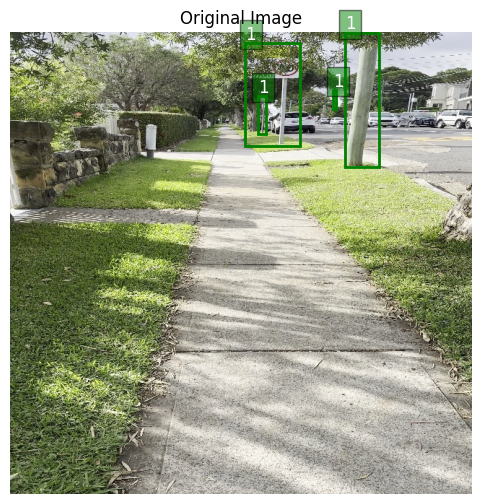

In [ ]:
###############################################################################
# 6B. Define a bounding box clamp helper
###############################################################################
def clamp_yolo_bbox(bbox):
    """
    Clamps YOLO bounding box [x_center, y_center, width, height]
    so that everything stays within [0,1].
    """
    x_center, y_center, width, height = bbox[:4]
    x_min = max(0, x_center - width / 2)
    y_min = max(0, y_center - height / 2)
    x_max = min(1, x_center + width / 2)
    y_max = min(1, y_center + height / 2)

    # Recompute new width, height, centers
    width = x_max - x_min
    height = y_max - y_min
    x_center = x_min + width / 2
    y_center = y_min + height / 2

    # Preserve any additional fields in bbox (e.g., class_id)
    return [x_center, y_center, width, height] + bbox[4:]

###############################################################################
# 6C. Demonstration on a single image 
###############################################################################
def plot_image_with_bboxes(image, bboxes, class_labels, title=''):
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    img_height, img_width = image.shape[:2]
    for bbox, cls in zip(bboxes, class_labels):
        x_center, y_center, w, h = bbox[:4]
        x_min = (x_center - w / 2) * img_width
        y_min = (y_center - h / 2) * img_height
        rect_w = w * img_width
        rect_h = h * img_height
        rect = plt.Rectangle((x_min, y_min), rect_w, rect_h,
                             linewidth=2, edgecolor='g', facecolor='none')
        plt.gca().add_patch(rect)
        plt.text(x_min, y_min - 5, str(cls), color='white', fontsize=12,
                 bbox=dict(facecolor='green', alpha=0.5))
    plt.title(title)
    plt.axis('off')
    plt.show()

sample_img_path = train_img_dir / "frame_IMG_6531_00014.jpg"
if sample_img_path.exists():
    # Load the sample image and label
    label_path = train_lbl_dir / (sample_img_path.stem + ".txt")
    image_bgr = cv2.imread(str(sample_img_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    with open(label_path, 'r') as f:
        lines = [line.strip().split() for line in f.readlines()]
    class_labels = [int(l[0]) for l in lines]
    bboxes = [list(map(float, l[1:])) for l in lines]
    bboxes = [clamp_yolo_bbox(bb) for bb in bboxes]

    print(f"Loaded {sample_img_path.name} with {len(bboxes)} bounding boxes.")
    plot_image_with_bboxes(image_rgb, bboxes, class_labels, title="Original Image")
else:
    print("Sample image for demonstration not found; skipping example preview.")

###############################################################################
# 6D. EXACT 5 Augmentations
###############################################################################
def partial_visible_aug(img):
    return A.Compose([
        A.RandomCrop(height=int(0.8*img.shape[0]), width=int(0.8*img.shape[1]), p=1.0),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def low_light_aug(img):
    return A.Compose([
        A.RandomBrightnessContrast(brightness_limit=(-0.3, 0.0),
                                   contrast_limit=(-0.3, 0.0), p=1.0),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def occlusion_aug(img):
    return A.Compose([
        A.CoarseDropout(max_holes=8, min_holes=4,
                        max_height=int(0.1*img.shape[0]),
                        max_width=int(0.1*img.shape[1]),
                        fill_value=0, p=1.0),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def crowded_aug(img):
    return A.Compose([
        A.GridDropout(ratio=0.3, p=1.0),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def perspective_aug(img):
    return A.Compose([
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=10, p=1.0),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Create a dictionary with these 5 named augmentations:
augmentations = {
    'partial_visible': partial_visible_aug,
    'low_light': low_light_aug,
    'occlusion': occlusion_aug,
    'crowded': crowded_aug,
    'perspective': perspective_aug
}

In [ ]:
###############################################################################
# 6E. Generate +30% Augmented Data (distributed among the 5 augmentations)
###############################################################################
train_images = list(train_img_dir.glob("*.jpg"))
total_images = len(train_images) 
target_augmented = int(total_images * 0.3)  # => ~30%
num_per_type = target_augmented // len(augmentations)  # how many for each aug type

print(f"Target: {target_augmented} augmented images total (~30% of {total_images}).")
print(f"=> {num_per_type} per augmentation type (5 types).")

# Shuffle so we pick random images for each augmentation type
random.shuffle(train_images)

idx_start = 0
for aug_type, aug_func in augmentations.items():
    # Slice images for this augmentation type
    subset = train_images[idx_start : idx_start + num_per_type]
    idx_start += num_per_type

    print(f"Generating {len(subset)} augmented images for '{aug_type}'...")

    for img_path in subset:
        lbl_path = train_lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue
        image_bgr = cv2.imread(str(img_path))
        if image_bgr is None:
            continue
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        with open(lbl_path, 'r') as f:
            lines = [line.strip().split() for line in f.readlines()]
        class_labels = [int(l[0]) for l in lines]
        bboxes = [list(map(float, l[1:])) for l in lines]
        bboxes = [clamp_yolo_bbox(bb) for bb in bboxes]

        # Build the augmentation pipeline
        pipeline = aug_func(image_rgb)  # call the function to get A.Compose
        transformed = pipeline(image=image_rgb, bboxes=bboxes, class_labels=class_labels)
        aug_image = transformed['image']
        aug_bboxes = transformed['bboxes']
        aug_class_labels = transformed['class_labels']

        # Re-clamp after transformation
        aug_bboxes = [clamp_yolo_bbox(b) for b in aug_bboxes]

        # Save with a special suffix
        aug_filename = f"{img_path.stem}_{aug_type}.jpg"
        aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(aug_img_dir / aug_filename), aug_image_bgr)

        with open(aug_lbl_dir / f"{img_path.stem}_{aug_type}.txt", 'w') as f:
            for cls_id, bb in zip(aug_class_labels, aug_bboxes):
                x, y, w, h = bb[:4]
                f.write(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

    print(f"Done with '{aug_type}' augmentation.")

# Count how many actually got generated
num_augmented = len(list(aug_img_dir.glob("*.jpg")))
print(f"\nTotal augmented images generated: {num_augmented}")


Target: 562 augmented images total (~30% of 1876).
=> 112 per augmentation type (5 types).
Generating 112 augmented images for 'partial_visible'...
Done with 'partial_visible' augmentation.
Generating 112 augmented images for 'low_light'...


/usr/local/lib/python3.11/dist-packages/albumentations/core/composition.py:250: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


Done with 'low_light' augmentation.
Generating 112 augmented images for 'occlusion'...


<ipython-input-12-b39e9f1756f4>:84: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, min_holes=4,


Done with 'occlusion' augmentation.
Generating 112 augmented images for 'crowded'...
Done with 'crowded' augmentation.
Generating 112 augmented images for 'perspective'...


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Done with 'perspective' augmentation.

Total augmented images generated: 560


In [14]:
###############################################################################
# 6F. Create train_augmented.txt with original + augmented
###############################################################################
train_augmented_txt = benchmarking_v1_dir / "train_augmented.txt"
with open(train_augmented_txt, 'w') as f:
    # 1) all original training images
    for p in train_img_dir.glob("*.jpg"):
        f.write(str(p) + "\n")
    # 2) new augmented images
    for p in aug_img_dir.glob("*.jpg"):
        f.write(str(p) + "\n")

print(f"Created {train_augmented_txt} combining original + augmented images.")


Created /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/train_augmented.txt combining original + augmented images.


In [15]:
###############################################################################
# CELL #7: TRAIN MULTIPLE YOLO MODELS ON ORIGINAL DATASET
###############################################################################
device = 0 if torch.cuda.is_available() else 'cpu'
EPOCHS = 100
BATCH  = 16
IMGSZ  = 640

# Paths to data files
data_original_yaml = benchmarking_v1_dir / "data_original.yaml"
# The path to your YOLOv11 weights in Google Drive
YOLOV11_BASE = benchmarking_v1_dir / "yolo11_models"

# Our global results dictionary
results_summary = {}

# Models to train: YOLOv11n, YOLOv11s, YOLOv11m
models_to_train = [
    (f"{YOLOV11_BASE}/yolo11n.pt", "v11nano"),
    (f"{YOLOV11_BASE}/yolo11s.pt", "v11small"),
    (f"{YOLOV11_BASE}/yolo11m.pt", "v11medium")
]

def train_and_eval_original(model_path, nickname):
    """
    Trains a YOLO model on the ORIGINAL dataset only,
    then evaluates on the test set, storing final results in results_summary.
    """
    from ultralytics import YOLO
    model = YOLO(model_path)

    run_name = f"{nickname}_original"
    print(f"\n--- Training {model_path} on {data_original_yaml} => run: {run_name} ---")

    # Train
    results = model.train(
        data=str(data_original_yaml),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        lr0=0.0006,
        warmup_epochs=3,
        device=device,
        name=run_name,
        project=str(benchmarking_v1_dir / "runs/train"),
        patience=10,
        verbose=True,
        plots=True,
        augment=True,
        mosaic=0,
        mixup=0,
        degrees=5,
        translate=0.05,
        scale=0.1,
        shear=0.0,
        hsv_h=0.005,
        hsv_s=0.3,
        hsv_v=0.2
    )

    # Evaluate on test
    print(f"\n--- Validating {run_name} on test split ---")
    val_results = model.val(data=str(data_original_yaml), split='test')

    # Because val_results.box.p and box.r are arrays, compute mean precision/recall
    p_mean = val_results.box.p.mean()
    r_mean = val_results.box.r.mean()
    map50  = val_results.box.map50
    map5095= val_results.box.map

    # Print summary
    print(f"{run_name} => mAP50={map50:.4f}, "
          f"mAP50-95={map5095:.4f}, "
          f"Precision={p_mean:.4f}, "
          f"Recall={r_mean:.4f}")

    # Store final mAP50-95 in results_summary
    results_summary[run_name] = map5095


print("=== TRAINING ON ORIGINAL DATASET ===")
for model_path, nickname in models_to_train:
    train_and_eval_original(model_path, nickname)

print("\nAll original-dataset training runs complete.")
print("Current summary of final mAP50-95 on test set:")
for k, v in results_summary.items():
    print(f"  {k}: {v:.4f}")


=== TRAINING ON ORIGINAL DATASET ===


100%|██████████| 5.35M/5.35M [00:00<00:00, 63.2MB/s]



--- Training /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/yolo11_models/yolo11n.pt on /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/data_original.yaml => run: v11nano_original ---
Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/yolo11_models/yolo11n.pt, data=/content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/data_original.yaml, epochs=100, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=/content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train, name=v11nano_original, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_s

100%|██████████| 755k/755k [00:00<00:00, 14.5MB/s]


Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

...


100 epochs completed in 0.598 hours.
Optimizer stripped from /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_original/weights/last.pt, 40.5MB
Optimizer stripped from /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_original/weights/best.pt, 40.5MB

Validating /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_original/weights/best.pt...
Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11m summary (fused): 125 layers, 20,033,887 parameters, 0 gradients, 67.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03<00:00,  4.02it/s]


                   all        402        280      0.795      0.724      0.801      0.536
                  hole          4         14       0.79      0.857      0.884        0.5
                  pole         81        199      0.849      0.792      0.885      0.567
                stairs         20         21      0.662      0.559      0.679      0.462
                bottle         21         26      0.904      0.962      0.972      0.807
                  rock         13         20       0.77       0.45      0.586      0.346
Speed: 0.1ms preprocess, 5.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_original

--- Validating v11medium_original on test split ---
Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11m summary (fused): 125 layers, 20,033,887 parameters, 0 gradients, 67.7 GFLOPs


val: Scanning /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/labels/test.cache... 403 images, 274 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:04<00:00,  5.52it/s]


                   all        403        272      0.752      0.669      0.717      0.458
                  hole          7         15      0.869      0.445      0.604      0.314
                  pole         66        186       0.82      0.801      0.829      0.499
                stairs         28         31      0.596      0.548      0.622      0.402
                bottle         16         20      0.736          1      0.974      0.793
                  rock         16         20      0.738       0.55      0.557       0.28
Speed: 0.7ms preprocess, 7.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_original2
v11medium_original => mAP50=0.7170, mAP50-95=0.4577, Precision=0.7517, Recall=0.6690

All original-dataset training runs complete.
Current summary of final mAP50-95 on test set:
  v11nano_original: 0.4278
  v11small_original: 0.3501
  v11medium_original: 0.4577


In [17]:
data_augmented_yaml = benchmarking_v1_dir / "data_augmented.yaml"
with open(data_augmented_yaml, 'w') as f:
    f.write(f"train: {train_augmented_txt}\n")
    f.write(f"val: {val_txt}\n")
    f.write(f"test: {test_txt}\n")
    f.write(f"nc: {len(selected_classes)}\n")
    f.write(f"names: {selected_classes}\n")

print(f"Created data_augmented.yaml => {data_augmented_yaml}")


Created data_augmented.yaml => /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/data_augmented.yaml


In [18]:
###############################################################################
# CELL #8: TRAIN MULTIPLE YOLO MODELS ON AUGMENTED DATASET
###############################################################################
device = 0 if torch.cuda.is_available() else 'cpu'

# Reuse the same YOLOv11 models
models_to_train = [
    (f"{YOLOV11_BASE}/yolo11n.pt", "v11nano"),
    (f"{YOLOV11_BASE}/yolo11s.pt", "v11small"),
    (f"{YOLOV11_BASE}/yolo11m.pt", "v11medium")
]

def train_and_eval_augmented(model_path, nickname):
    """
    Trains a YOLO model on the AUGMENTED dataset only,
    then evaluates on the test set, storing final results in results_summary.
    """
    from ultralytics import YOLO
    model = YOLO(model_path)

    run_name = f"{nickname}_augmented"
    print(f"\n--- Training {model_path} on {data_augmented_yaml} => run: {run_name} ---")

    # Train
    results = model.train(
        data=str(data_augmented_yaml),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        lr0=0.0006,
        warmup_epochs=3,
        device=device,
        name=run_name,
        project=str(benchmarking_v1_dir / "runs/train"),
        patience=10,
        verbose=True,
        plots=True,
        augment=True,
        mosaic=0,
        mixup=0,
        degrees=5,
        translate=0.05,
        scale=0.1,
        shear=0.0,
        hsv_h=0.005,
        hsv_s=0.3,
        hsv_v=0.2
    )

    # Evaluate on test
    print(f"\n--- Validating {run_name} on test split ---")
    val_results = model.val(data=str(data_augmented_yaml), split='test')

    # Because val_results.box.p and box.r are arrays, compute mean precision/recall
    p_mean = val_results.box.p.mean()
    r_mean = val_results.box.r.mean()
    map50  = val_results.box.map50
    map5095= val_results.box.map

    # Print summary
    print(f"{run_name} => mAP50={map50:.4f}, "
          f"mAP50-95={map5095:.4f}, "
          f"Precision={p_mean:.4f}, "
          f"Recall={r_mean:.4f}")

    # Store final mAP50-95 in results_summary
    results_summary[run_name] = map5095


print("=== TRAINING ON AUGMENTED DATASET ===")
for model_path, nickname in models_to_train:
    train_and_eval_augmented(model_path, nickname)

print("\nAll augmented-dataset training runs complete.")
print("Final summary of all mAP50-95 on test set (original + augmented):")
for k, v in results_summary.items():
    print(f"  {k}: {v:.4f}")


=== TRAINING ON AUGMENTED DATASET ===

--- Training /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/yolo11_models/yolo11n.pt on /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/data_augmented.yaml => run: v11nano_augmented ---
Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/yolo11_models/yolo11n.pt, data=/content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/data_augmented.yaml, epochs=100, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=/content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train, name=v11nano_augmented2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fracti

train: Scanning /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/labels/aug... 2436 images, 1631 backgrounds, 0 corrupt: 100%|██████████| 2436/2436 [00:09<00:00, 260.39it/s]


train: New cache created: /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/labels/aug.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/labels/val.cache... 402 images, 265 backgrounds, 0 corrupt: 100%|██████████| 402/402 [00:00<?, ?it/s]


Plotting labels to /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11nano_augmented2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.0006' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11nano_augmented2
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


73 epochs completed in 0.547 hours.
Optimizer stripped from /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_augmented/weights/last.pt, 40.5MB
Optimizer stripped from /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_augmented/weights/best.pt, 40.5MB

Validating /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_augmented/weights/best.pt...
Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11m summary (fused): 125 layers, 20,033,887 parameters, 0 gradients, 67.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03<00:00,  4.13it/s]


                   all        402        280      0.726      0.754      0.774      0.521
                  hole          4         14      0.559      0.723      0.725      0.434
                  pole         81        199      0.779      0.834      0.853      0.529
                stairs         20         21      0.624      0.714      0.711      0.508
                bottle         21         26      0.911          1       0.99      0.776
                  rock         13         20      0.756        0.5      0.591      0.356
Speed: 0.1ms preprocess, 5.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_augmented

--- Validating v11medium_augmented on test split ---
Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11m summary (fused): 125 layers, 20,033,887 parameters, 0 gradients, 67.7 GFLOPs


val: Scanning /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/labels/test.cache... 403 images, 274 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:04<00:00,  5.60it/s]


                   all        403        272      0.579      0.666      0.643      0.423
                  hole          7         15       0.56      0.341      0.401      0.223
                  pole         66        186      0.588      0.801      0.767      0.428
                stairs         28         31      0.689      0.788       0.76      0.517
                bottle         16         20      0.692          1      0.988       0.78
                  rock         16         20      0.364        0.4      0.298      0.165
Speed: 0.6ms preprocess, 6.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/runs/train/v11medium_augmented2
v11medium_augmented => mAP50=0.6428, mAP50-95=0.4227, Precision=0.5787, Recall=0.6659

All augmented-dataset training runs complete.
Final summary of all mAP50-95 on test set (original + augmented):
  v11nano_original: 0.4278
  v11small_original: 0.3501
  v11medium_ori

In [19]:
print("Complete Summary of Final mAP50-95 (All Models + Datasets):")
for k, v in results_summary.items():
    print(f"  {k}: {v:.4f}")

Complete Summary of Final mAP50-95 (All Models + Datasets):
  v11nano_original: 0.4278
  v11small_original: 0.3501
  v11medium_original: 0.4577
  v11nano_augmented: 0.4985
  v11small_augmented: 0.5192
  v11medium_augmented: 0.4227


In [20]:
###############################################################################
# CELL #8: VISUALIZE TEST PREDICTIONS FROM ORIGINAL & AUGMENTED MODELS
###############################################################################
TEST_IMGS = list(test_img_dir.glob("*.jpg"))
NUM_SAMPLES = 3  # how many test images to sample

def visualize_predictions(model, image_paths, out_dir, prefix=""):
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    samples = random.sample(image_paths, min(NUM_SAMPLES, len(image_paths)))

    for img_path in samples:
        results = model.predict(str(img_path), conf=0.25)
        annotated = results[0].plot()
        save_name = f"{prefix}{img_path.stem}_pred.jpg"
        cv2.imwrite(str(out_path / save_name), annotated)
        print(f"✅ Saved {save_name} in {out_path.name}")

# List of (model_name, dataset_variant)
models_to_visualize = [
    ("v11nano", "original"),
    ("v11nano", "augmented"),
    ("v11small", "original"),
    ("v11small", "augmented"),
    ("v11medium", "original"),
    ("v11medium", "augmented"),
]

for model_tag, dataset_variant in models_to_visualize:
    weights_path = benchmarking_v1_dir / "runs/train" / f"{model_tag}_{dataset_variant}" / "weights/best.pt"
    if weights_path.exists():
        model = YOLO(str(weights_path))
        out_dir = benchmarking_v1_dir / "runs" / "predictions" / f"{model_tag}_{dataset_variant}"
        prefix = f"{model_tag}_{dataset_variant}_"  # To distinguish in filename
        print(f"\n📸 Visualizing predictions for: {model_tag} trained on {dataset_variant}...")
        visualize_predictions(model, TEST_IMGS, out_dir, prefix=prefix)
    else:
        print(f"No weights found for {model_tag}_{dataset_variant}. Skipping.")




📸 Visualizing predictions for: v11nano trained on original...

image 1/1 /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/images/test/frame_IMG_4326_00030.jpg: 640x640 (no detections), 9.7ms
Speed: 2.2ms preprocess, 9.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved v11nano_original_frame_IMG_4326_00030_pred.jpg in v11nano_original

image 1/1 /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/images/test/frame_IMG_4941_00014.jpg: 640x640 (no detections), 10.1ms
Speed: 3.0ms preprocess, 10.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved v11nano_original_frame_IMG_4941_00014_pred.jpg in v11nano_original

image 1/1 /content/drive/MyDrive/EnigmaAI_temp/benchmarking/benchmarking_v1/images/test/frame_IMG_4956_00005.jpg: 640x640 2 poles, 10.7ms
Speed: 1.8ms preprocess, 10.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
✅ Saved v11nano_original_frame_IMG_4956_00005_pred.jpg in v11nano